# Image Classification on Tiny ImageNet: ResNet vs EfficientNet vs ViT

This notebook trains and evaluates three architectures on **Tiny ImageNet**
(200 classes, 64x64 images, 100,000 training images, 10,000 labeled
validation images):

- **ResNet-18** (CNN)
- **EfficientNet-B0** (CNN)
- **ViT-B/16** (Vision Transformer)


## 1. Setup & Installs

In [1]:
# Uncomment if running in a fresh environment (e.g. Colab)
# !pip install -q torch torchvision scikit-learn matplotlib seaborn tqdm pandas


In [2]:
import os
import copy
import random
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from PIL import Image

import torchvision
from torchvision import transforms
from torchvision.models import (
    resnet18, ResNet18_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
    vit_b_16, ViT_B_16_Weights,
)

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## 2. Download Tiny ImageNet



Folder layout after extraction:
```
tiny-imagenet-200/
  wnids.txt                  # 200 class IDs (one per line)
  words.txt                  # class ID -> human-readable name
  train/<wnid>/images/*.JPEG # 500 images per class
  val/images/*.JPEG          # 10,000 images
  val/val_annotations.txt    # filename -> wnid label for the val set
  test/images/*.JPEG         # 10,000 UNLABELED images (not used here)
```


In [3]:
DATA_ROOT = "./data"
ZIP_URL = "http://cs231n.stanford.edu/tiny-imagenet-200.zip"
ZIP_PATH = os.path.join(DATA_ROOT, "tiny-imagenet-200.zip")
EXTRACT_DIR = os.path.join(DATA_ROOT, "tiny-imagenet-200")

os.makedirs(DATA_ROOT, exist_ok=True)

if not os.path.isdir(EXTRACT_DIR):
    if not os.path.isfile(ZIP_PATH):
        print("Downloading Tiny ImageNet (~237 MB)...")

        class DownloadProgressBar(tqdm):
            def update_to(self, b=1, bsize=1, tsize=None):
                if tsize is not None:
                    self.total = tsize
                self.update(b * bsize - self.n)

        with DownloadProgressBar(unit="B", unit_scale=True, miniters=1, desc="tiny-imagenet-200.zip") as t:
            urllib.request.urlretrieve(ZIP_URL, ZIP_PATH, reporthook=t.update_to)

    print("Extracting...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(DATA_ROOT)
    print("Done.")
else:
    print("Tiny ImageNet already present at", EXTRACT_DIR)


Tiny ImageNet already present at ./data\tiny-imagenet-200


## 3. Build the Datasets

We build two custom `Dataset` classes:

- `TinyImageNetTrain` — reads `train/<wnid>/images/*.JPEG` for all 200 classes.
- `TinyImageNetVal` — reads `val/images/*.JPEG` and maps each filename to its
  label using `val_annotations.txt`.

Class-index order is fixed by the sorted order of `wnids.txt`, so both
datasets share a consistent label space.


In [4]:
with open(os.path.join(EXTRACT_DIR, "wnids.txt")) as f:
    wnids = [line.strip() for line in f.readlines()]
wnids.sort()
wnid_to_idx = {wnid: i for i, wnid in enumerate(wnids)}
num_classes = len(wnids)

# Human-readable names (words.txt has many extra ids; keep only ours)
words = {}
with open(os.path.join(EXTRACT_DIR, "words.txt")) as f:
    for line in f:
        wnid, name = line.strip().split("\t")
        if wnid in wnid_to_idx:
            words[wnid] = name.split(",")[0]

class_names = [words.get(w, w) for w in wnids]
print(f"Number of classes: {num_classes}")
print("Example classes:", class_names[:5])


Number of classes: 200
Example classes: ['goldfish', 'European fire salamander', 'bullfrog', 'tailed frog', 'American alligator']


In [5]:
class TinyImageNetTrain(Dataset):
    def __init__(self, root, wnid_to_idx, transform=None):
        self.transform = transform
        self.samples = []  # list of (filepath, label)
        train_dir = os.path.join(root, "train")
        for wnid, idx in wnid_to_idx.items():
            img_dir = os.path.join(train_dir, wnid, "images")
            for fname in os.listdir(img_dir):
                if fname.lower().endswith(".jpeg"):
                    self.samples.append((os.path.join(img_dir, fname), idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


class TinyImageNetVal(Dataset):
    def __init__(self, root, wnid_to_idx, transform=None):
        self.transform = transform
        self.samples = []
        val_dir = os.path.join(root, "val")
        img_dir = os.path.join(val_dir, "images")
        ann_path = os.path.join(val_dir, "val_annotations.txt")
        with open(ann_path) as f:
            for line in f:
                parts = line.strip().split("\t")
                fname, wnid = parts[0], parts[1]
                if wnid in wnid_to_idx:
                    self.samples.append((os.path.join(img_dir, fname), wnid_to_idx[wnid]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


In [6]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomCrop(IMG_SIZE, padding=16),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Two copies of the training pool with different transforms, so we can split
# indices once and reuse them for both the augmented-train and clean-val subsets.
train_full_aug = TinyImageNetTrain(EXTRACT_DIR, wnid_to_idx, transform=train_transform)
train_full_eval = TinyImageNetTrain(EXTRACT_DIR, wnid_to_idx, transform=eval_transform)

# Official validation set doubles as our held-out TEST set (it has real labels;
# the official "test" folder does not).
test_ds = TinyImageNetVal(EXTRACT_DIR, wnid_to_idx, transform=eval_transform)

print(f"Train pool: {len(train_full_aug)} | Test (official val): {len(test_ds)}")


Train pool: 100000 | Test (official val): 10000


In [7]:
# Carve out 10% of the training pool as our validation set for model selection
n_total = len(train_full_aug)
indices = list(range(n_total))
random.shuffle(indices)
n_val = int(0.10 * n_total)

val_idx = indices[:n_val]
train_idx = indices[n_val:]

train_ds = Subset(train_full_aug, train_idx)   # augmented transform
val_ds = Subset(train_full_eval, val_idx)      # clean transform

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

BATCH_SIZE = 128
NUM_WORKERS = 0

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)


Train: 90000 | Val: 10000 | Test: 10000


## 4. Model Builders

Each model is loaded with ImageNet-pretrained weights and its final
classification layer is replaced to output `num_classes` (200) logits.


In [8]:
def build_model(name: str, num_classes: int) -> nn.Module:
    name = name.lower()

    if name == "resnet18":
        weights = ResNet18_Weights.DEFAULT
        model = resnet18(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    elif name == "efficientnet_b0":
        weights = EfficientNet_B0_Weights.DEFAULT
        model = efficientnet_b0(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    elif name == "vit_b_16":
        weights = ViT_B_16_Weights.DEFAULT
        model = vit_b_16(weights=weights)
        in_features = model.heads.head.in_features
        model.heads.head = nn.Linear(in_features, num_classes)

    else:
        raise ValueError(f"Unknown model name: {name}")

    return model.to(device)


## 5. Training & Evaluation Utilities

`train_model` fine-tunes for a given number of epochs and tracks the best
validation accuracy checkpoint. `evaluate_model` computes accuracy,
precision/recall/F1 (macro & weighted), a full classification report,
and a confusion matrix on the test set.


In [9]:
def train_model(model, train_loader, val_loader, epochs=5, lr=1e-4, model_name="model"):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_acc = 0.0
    best_state = copy.deepcopy(model.state_dict())
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        # ---- Train ----
        model.train()
        running_loss = 0.0
        for imgs, labels in tqdm(train_loader, desc=f"[{model_name}] Epoch {epoch+1}/{epochs} - train"):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        # ---- Validate ----
        model.eval()
        val_loss = 0.0
        correct = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = correct / len(val_loader.dataset)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"[{model_name}] Epoch {epoch+1}/{epochs} "
              f"- train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return model, history


def evaluate_model(model, test_loader, class_names, model_name="model"):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in tqdm(test_loader, desc=f"[{model_name}] evaluating"):
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0)
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="weighted", zero_division=0)

    print(f"\n=== {model_name} Test Metrics ===")
    print(f"Accuracy:            {acc:.4f}")
    print(f"Precision (macro):   {precision_macro:.4f}")
    print(f"Recall (macro):      {recall_macro:.4f}")
    print(f"F1-score (macro):    {f1_macro:.4f}")
    print(f"Precision (weighted):{precision_weighted:.4f}")
    print(f"Recall (weighted):   {recall_weighted:.4f}")
    print(f"F1-score (weighted): {f1_weighted:.4f}\n")

    report = classification_report(
        all_labels, all_preds, target_names=class_names, zero_division=0
    )
    print(report)

    metrics = {
        "model": model_name,
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "y_true": all_labels,
        "y_pred": all_preds,
        "report": report,
    }
    return metrics


def plot_confusion_matrix(y_true, y_pred, class_names, model_name="model", max_labels_shown=30):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    # With 200 classes a full label set is unreadable; show ticks only if class count is small
    show_labels = len(class_names) <= max_labels_shown
    sns.heatmap(cm, cmap="viridis",
                xticklabels=class_names if show_labels else False,
                yticklabels=class_names if show_labels else False)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


def plot_training_curves(history, model_name="model"):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs, history["val_loss"], label="Val Loss")
    axes[0].set_title(f"{model_name} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(epochs, history["val_acc"], label="Val Accuracy", color="green")
    axes[1].set_title(f"{model_name} - Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


## 6. Training Configuration




In [10]:
EPOCHS = 10
LR = 1e-4

all_results = {}   # model_name -> metrics dict
all_histories = {} # model_name -> training history


## 7. ResNet-18

In [11]:
resnet_model = build_model("resnet18", num_classes)
resnet_model, resnet_history = train_model(
    resnet_model, train_loader, val_loader, epochs=EPOCHS, lr=LR, model_name="ResNet18"
)
all_histories["ResNet18"] = resnet_history


[ResNet18] Epoch 1/10 - train:   0%|          | 0/704 [00:00<?, ?it/s]

[ResNet18] Epoch 1/10 - train_loss: 2.5624 - val_loss: 1.6133 - val_acc: 0.6180


[ResNet18] Epoch 2/10 - train:   0%|          | 0/704 [00:00<?, ?it/s]

[ResNet18] Epoch 2/10 - train_loss: 1.3431 - val_loss: 1.3086 - val_acc: 0.6756


[ResNet18] Epoch 3/10 - train:   0%|          | 0/704 [00:00<?, ?it/s]

...

[ResNet18] Epoch 8/10 - train_loss: 0.3400 - val_loss: 1.0771 - val_acc: 0.7271


[ResNet18] Epoch 9/10 - train:   0%|          | 0/704 [00:00<?, ?it/s]

[ResNet18] Epoch 9/10 - train_loss: 0.2965 - val_loss: 1.0710 - val_acc: 0.7288


[ResNet18] Epoch 10/10 - train:   0%|          | 0/704 [00:00<?, ?it/s]

[ResNet18] Epoch 10/10 - train_loss: 0.2718 - val_loss: 1.0693 - val_acc: 0.7309


[ResNet18] evaluating:   0%|          | 0/79 [00:00<?, ?it/s]


=== ResNet18 Test Metrics ===
Accuracy:            0.7315
Precision (macro):   0.7355
Recall (macro):      0.7315
F1-score (macro):    0.7315
Precision (weighted):0.7355
Recall (weighted):   0.7315
F1-score (weighted): 0.7315

                          precision    recall  f1-score   support

                goldfish       0.87      0.94      0.90        50
European fire salamander       0.85      0.82      0.84        50
                bullfrog       0.72      0.68      0.70        50
             tailed frog       0.56      0.62      0.59        50
      American alligator       0.71      0.74      0.73        50
         boa constrictor       0.60      0.56      0.58        50
               trilobite       0.92      0.88      0.90        50
                scorpion       0.67      0.70      0.69        50
             black widow       0.86      0.88      0.87        50
               tarantula       0.74      0.74      0.74        50
               centipede       0.78      0.78

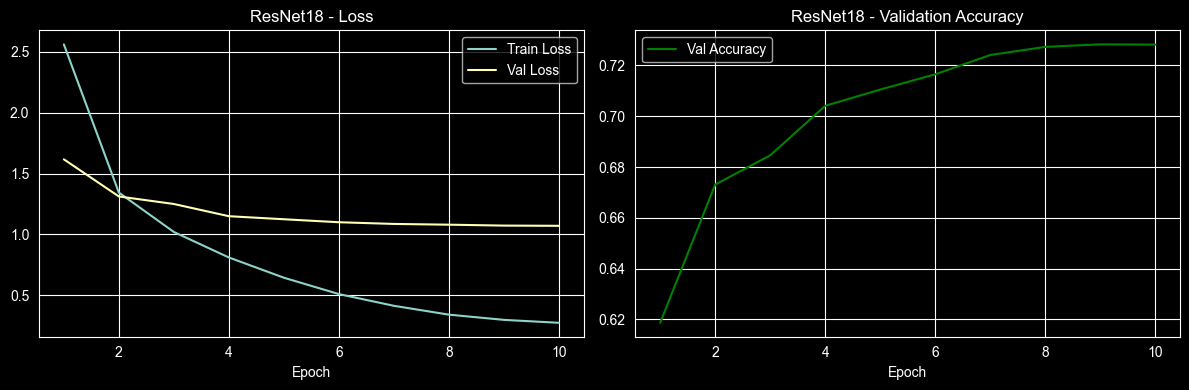

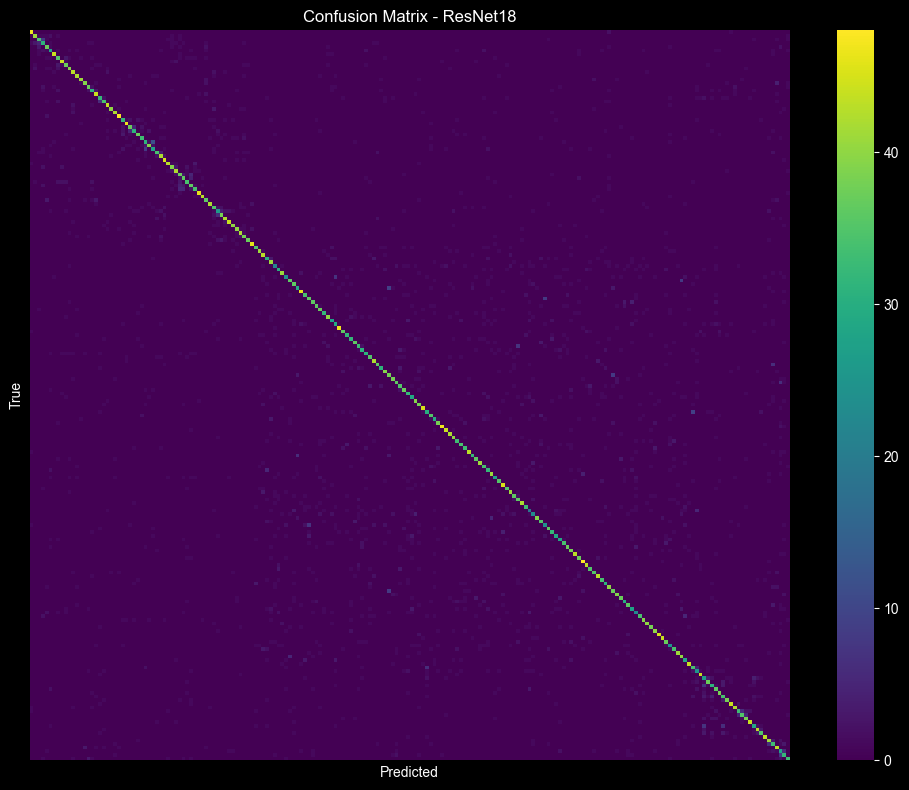

In [14]:
resnet_metrics = evaluate_model(resnet_model, test_loader, class_names, model_name="ResNet18")
all_results["ResNet18"] = resnet_metrics
plot_training_curves(resnet_history, "ResNet18")
plot_confusion_matrix(resnet_metrics["y_true"], resnet_metrics["y_pred"], class_names, "ResNet18")


## 8. EfficientNet-B0

In [12]:
effnet_model = build_model("efficientnet_b0", num_classes)
effnet_model, effnet_history = train_model(
    effnet_model, train_loader, val_loader, epochs=EPOCHS, lr=LR, model_name="EfficientNet-B0"
)
all_histories["EfficientNet-B0"] = effnet_history


[EfficientNet-B0] Epoch 1/10 - train:   0%|          | 0/704 [00:00<?, ?it/s]

[EfficientNet-B0] Epoch 1/10 - train_loss: 2.5342 - val_loss: 1.1319 - val_acc: 0.7212


[EfficientNet-B0] Epoch 2/10 - train:   0%|          | 0/704 [00:00<?, ?it/s]

[EfficientNet-B0] Epoch 2/10 - train_loss: 1.0546 - val_loss: 0.8949 - val_acc: 0.7698


[EfficientNet-B0] Epoch 3/10 - train:   0%|          | 0/704 [00:00<?, ?it/s]

...

[EfficientNet-B0] Epoch 8/10 - train_loss: 0.3968 - val_loss: 0.7671 - val_acc: 0.8031


[EfficientNet-B0] Epoch 9/10 - train:   0%|          | 0/704 [00:00<?, ?it/s]

[EfficientNet-B0] Epoch 9/10 - train_loss: 0.3738 - val_loss: 0.7627 - val_acc: 0.8042


[EfficientNet-B0] Epoch 10/10 - train:   0%|          | 0/704 [00:00<?, ?it/s]

[EfficientNet-B0] Epoch 10/10 - train_loss: 0.3610 - val_loss: 0.7650 - val_acc: 0.8047


[EfficientNet-B0] evaluating:   0%|          | 0/79 [00:00<?, ?it/s]


=== EfficientNet-B0 Test Metrics ===
Accuracy:            0.8106
Precision (macro):   0.8134
Recall (macro):      0.8106
F1-score (macro):    0.8102
Precision (weighted):0.8134
Recall (weighted):   0.8106
F1-score (weighted): 0.8102

                          precision    recall  f1-score   support

                goldfish       0.91      0.98      0.94        50
European fire salamander       0.94      0.90      0.92        50
                bullfrog       0.78      0.76      0.77        50
             tailed frog       0.76      0.78      0.77        50
      American alligator       0.84      0.74      0.79        50
         boa constrictor       0.72      0.84      0.78        50
               trilobite       0.89      0.94      0.91        50
                scorpion       0.91      0.82      0.86        50
             black widow       0.92      0.92      0.92        50
               tarantula       0.81      0.78      0.80        50
               centipede       0.87   

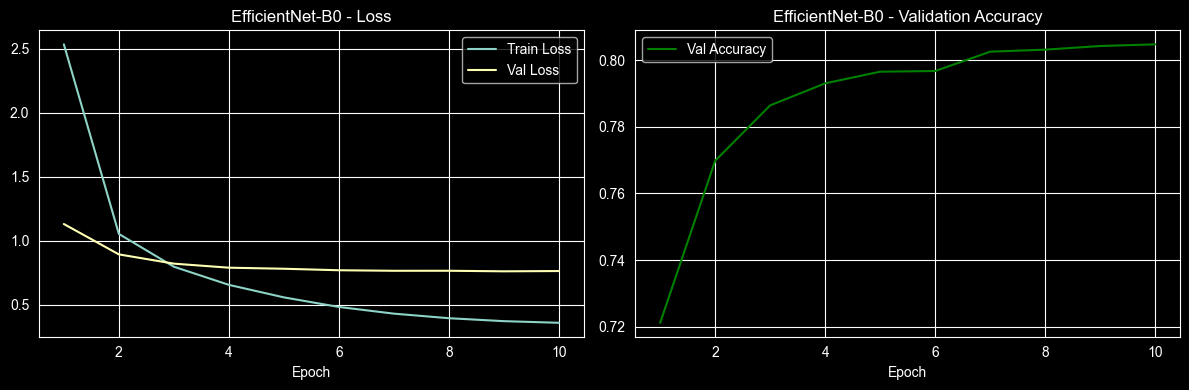

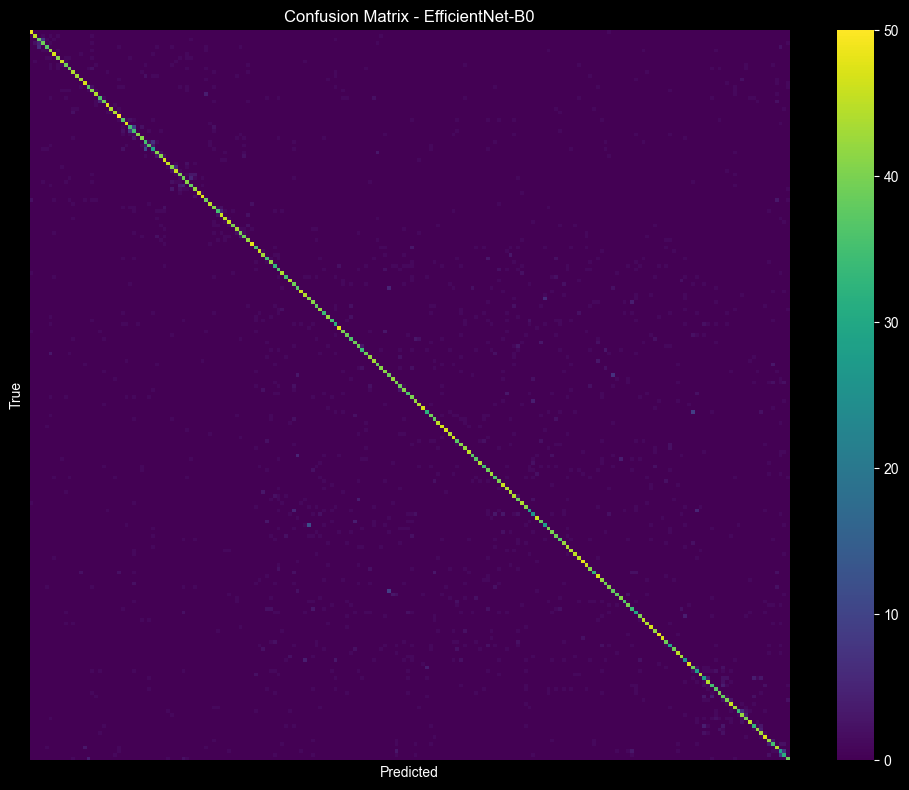

In [13]:
effnet_metrics = evaluate_model(effnet_model, test_loader, class_names, model_name="EfficientNet-B0")
all_results["EfficientNet-B0"] = effnet_metrics
plot_training_curves(effnet_history, "EfficientNet-B0")
plot_confusion_matrix(effnet_metrics["y_true"], effnet_metrics["y_pred"], class_names, "EfficientNet-B0")


## 9. Vision Transformer (ViT-B/16)

In [ ]:
vit_model = build_model("vit_b_16", num_classes)
vit_model, vit_history = train_model(
    vit_model, train_loader, val_loader, epochs=EPOCHS, lr=LR, model_name="ViT-B/16"
)
all_histories["ViT-B/16"] = vit_history


In [ ]:
vit_metrics = evaluate_model(vit_model, test_loader, class_names, model_name="ViT-B/16")
all_results["ViT-B/16"] = vit_metrics
plot_training_curves(vit_history, "ViT-B/16")
plot_confusion_matrix(vit_metrics["y_true"], vit_metrics["y_pred"], class_names, "ViT-B/16")


## 10. Model Comparison

Side-by-side comparison of all metrics across the three architectures.


In [ ]:
comparison_df = pd.DataFrame([
    {
        "Model": name,
        "Accuracy": m["accuracy"],
        "Precision (macro)": m["precision_macro"],
        "Recall (macro)": m["recall_macro"],
        "F1 (macro)": m["f1_macro"],
        "Precision (weighted)": m["precision_weighted"],
        "Recall (weighted)": m["recall_weighted"],
        "F1 (weighted)": m["f1_weighted"],
    }
    for name, m in all_results.items()
])

comparison_df = comparison_df.set_index("Model").round(4)
comparison_df


In [ ]:
# Bar chart comparing macro F1 / accuracy across models
fig, ax = plt.subplots(figsize=(8, 5))
comparison_df[["Accuracy", "F1 (macro)", "F1 (weighted)"]].plot(kind="bar", ax=ax)
ax.set_ylabel("Score")
ax.set_title("Model Comparison on Tiny ImageNet")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
